In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import random

# Reproducibility (Tekrarlanabilirlik) için rastgele tohum sabitleyelim
g = torch.Generator().manual_seed(2147483647)
random.seed(42)
print("PyTorch versiyonu:", torch.__version__)


PyTorch versiyonu: 2.14.0


In [2]:
# 1. Veriyi Oku
words = open('names.txt', 'r', encoding='utf-8').read().splitlines()
print(f"Toplam isim sayısı: {len(words)}")
print("İlk 5 isim:", words[:5])

# 2. Python Dictionary ile Bigram Sayımı
b = {}
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1

print("\nPython Dictionary ile En Çok Geçen 5 Bigram:")
sorted_b = sorted(b.items(), key=lambda x: x[1], reverse=True)
for bg, count in sorted_b[:5]:
    print(f"  {bg}: {count}")

# 3. Alphabet & Mapping (stoi, itos)
chars = sorted(list(set(''.join(words))))
stoi = {s: i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}

# 4. PyTorch 27x27 Tensor ile Sayım Tablosu
N = torch.zeros((27, 27), dtype=torch.int32)
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        N[ix1, ix2] += 1

print("\nSayım Tensor Boyutu:", N.shape)


Toplam isim sayısı: 32033
İlk 5 isim: ['emma', 'olivia', 'ava', 'isabella', 'sophia']

Python Dictionary ile En Çok Geçen 5 Bigram:
  ('n', '.'): 6763
  ('a', '.'): 6640
  ('a', 'n'): 5438
  ('.', 'a'): 4410
  ('e', '.'): 3983

Sayım Tensor Boyutu: torch.Size([27, 27])


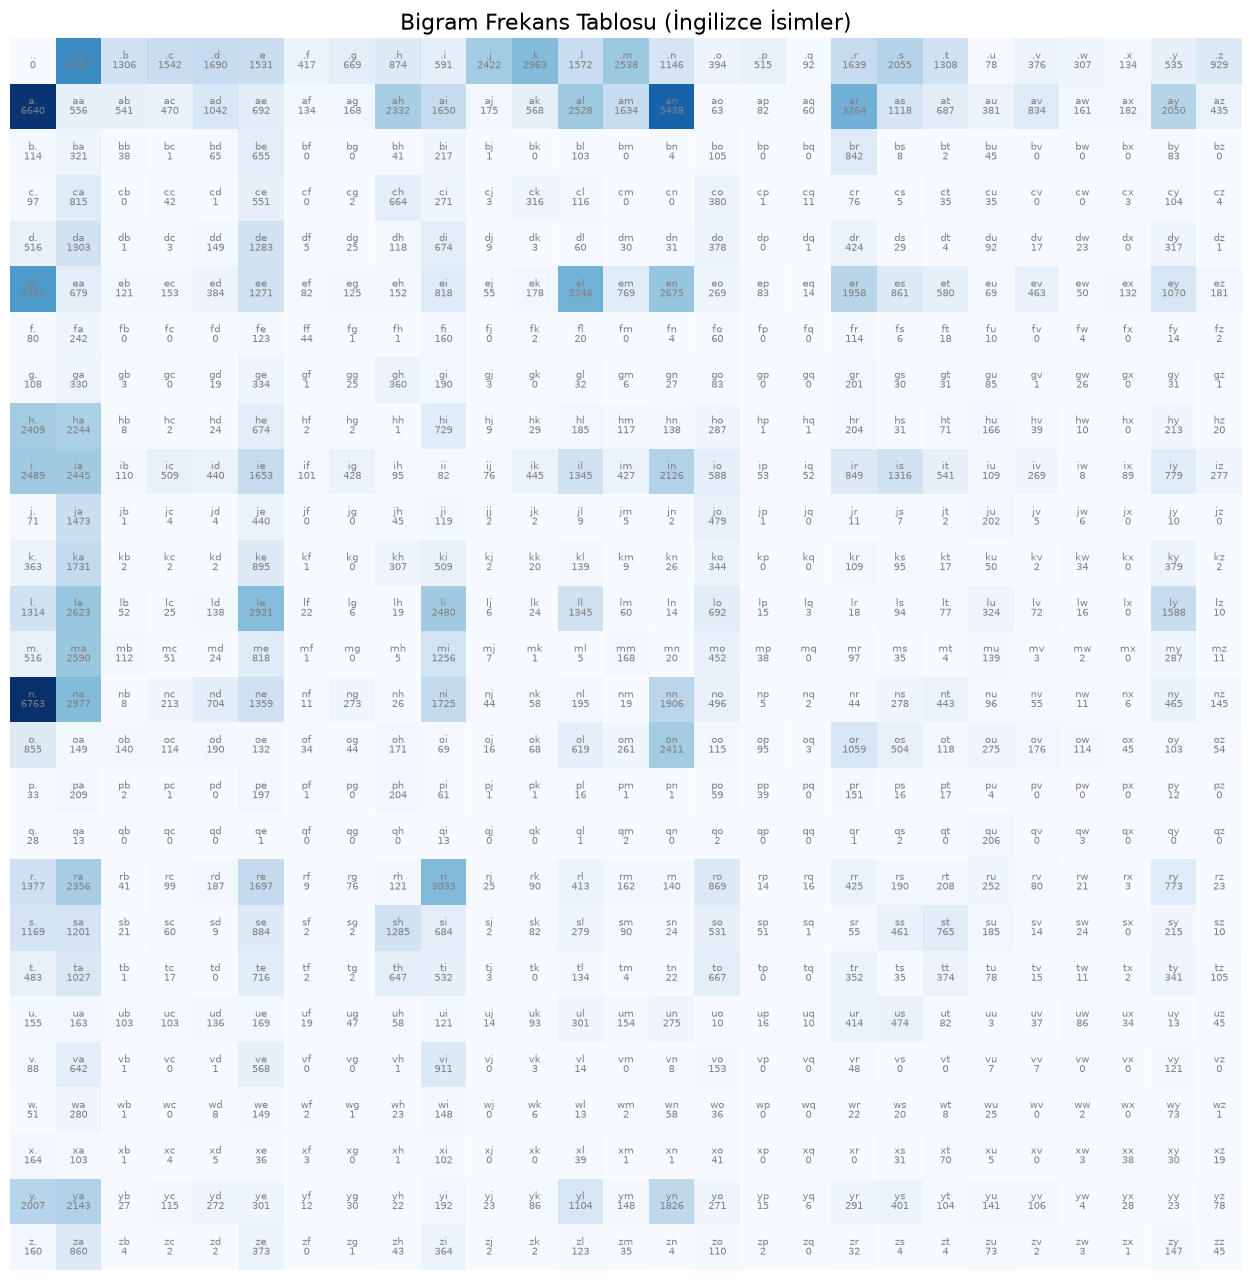

In [3]:
plt.figure(figsize=(16, 16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray', fontsize=7)
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray', fontsize=7)
plt.axis('off')
plt.title('Bigram Frekans Tablosu (İngilizce İsimler)', fontsize=16)
plt.show()


In [12]:
# Sayım tablosunu olasılık matrisine çevir (Laplace smoothing +1 eklenmiş hali)
P = (N + 1).float()
P /= P.sum(1, keepdim=True)

# Modelden Yeni İsimler Örnekleme (Sampling)
g = torch.Generator().manual_seed(2147483647)

print("Sayım Modelinden Üretilen İsim Örnekleri:")
for i in range(10):
    out = []
    ix = 0
    while True:
        p = P[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0:
            break
    print(f"  {i+1}. {''.join(out[:-1])}")


Sayım Modelinden Üretilen İsim Örnekleri:
  1. cexze
  2. momasurailezitynn
  3. konimittain
  4. llayn
  5. ka
  6. da
  7. staiyaubrtthrigotai
  8. moliellavo
  9. ke
  10. teda


In [5]:
log_likelihood = 0.0
n = 0

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1

nll = -log_likelihood
avg_nll = nll / n

print(f"Toplam Karakter Çifti Sayısı (n): {n}")
print(f"Log Likelihood: {log_likelihood.item():.4f}")
print(f"Negative Log Likelihood (NLL): {nll.item():.4f}")
print(f"Ortalama NLL Loss (Karakter Başına): {avg_nll.item():.4f}")


Toplam Karakter Çifti Sayısı (n): 228146
Log Likelihood: -559951.5625
Negative Log Likelihood (NLL): 559951.5625
Ortalama NLL Loss (Karakter Başına): 2.4544


In [6]:
# 1. Dataset Oluşturma (xs: girdi karakter indeksi, ys: hedef karakter indeksi)
xs, ys = [], []
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(f"Eğitim Örnek Sayısı: {num}")

# 2. Model Parametrelerinin Başlatılması
g = torch.Generator().manual_seed(2147483647)
W = torch.randn((27, 27), generator=g, requires_grad=True)

# 3. Gradient Descent Eğitimi Loop
losses = []
for k in range(200):
    # Forward Pass
    xenc = F.one_hot(xs, num_classes=27).float() # One-hot encoding
    logits = xenc @ W                           # Logits (tahmin skorları)
    counts = logits.exp()                        # exp() -> unnormalized counts
    probs = counts / counts.sum(1, keepdim=True) # Softmax
    
    # Negative Log Likelihood Loss (+ L2 regularization)
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01 * (W**2).mean()
    losses.append(loss.item())
    
    # Backward Pass (Micrograd ile aynı autograd mekanizması)
    W.grad = None
    loss.backward()
    
    # Parameter Update
    W.data += -50.0 * W.grad

print(f"Eğitim Sonu Sinir Ağı Loss Değeri: {loss.item():.4f}")
print(f"Sayım Modeli NLL Kaybı: {avg_nll.item():.4f}")
print("Görüldüğü üzere, Sinir Ağı kayıp değeri Sayım Modeline (Görev 3) tam olarak yaklaşmıştır!")


Eğitim Örnek Sayısı: 228146
Eğitim Sonu Sinir Ağı Loss Değeri: 2.4830
Sayım Modeli NLL Kaybı: 2.4544
Görüldüğü üzere, Sinir Ağı kayıp değeri Sayım Modeline (Görev 3) tam olarak yaklaşmıştır!


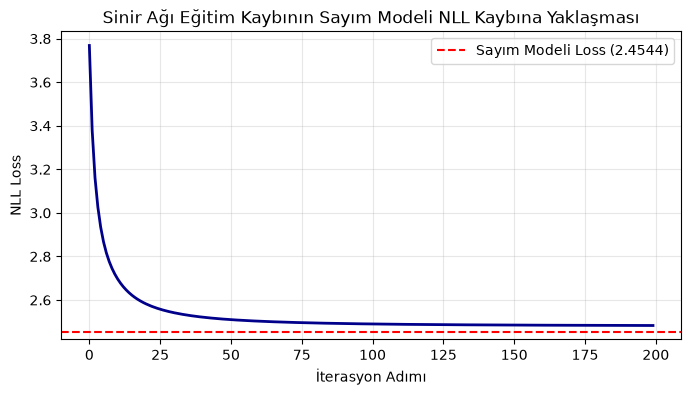

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(losses, color='darkblue', linewidth=2)
plt.axhline(y=avg_nll.item(), color='red', linestyle='--', label=f'Sayım Modeli Loss ({avg_nll.item():.4f})')
plt.xlabel('İterasyon Adımı')
plt.ylabel('NLL Loss')
plt.title('Sinir Ağı Eğitim Kaybının Sayım Modeli NLL Kaybına Yaklaşması')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [8]:
# 1. Türkçe Veriyi Oku ve Alfabeyi Tanımla
words_tr = open('names_tr.txt', 'r', encoding='utf-8').read().splitlines()
tr_chars = sorted(list(set(''.join(words_tr))))
print(f"Türkçe Veri Setindeki İsim Sayısı: {len(words_tr)}")
print(f"Türkçe Alfabe Karakter Sayısı ({len(tr_chars)}):", ''.join(tr_chars))

# Mapping
stoi_tr = {s: i+1 for i, s in enumerate(tr_chars)}
stoi_tr['.'] = 0
itos_tr = {i: s for s, i in stoi_tr.items()}
V_tr = len(stoi_tr) # Alfabe boyutu (33)

# 2. Türkçe Sayım Tablosu (N_tr)
N_tr = torch.zeros((V_tr, V_tr), dtype=torch.int32)
for w in words_tr:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi_tr[ch1]
        ix2 = stoi_tr[ch2]
        N_tr[ix1, ix2] += 1

# Olasılık Matrisi (P_tr)
P_tr = (N_tr + 1).float()
P_tr /= P_tr.sum(1, keepdim=True)

# Türkçe Sayım Modeli NLL Hesaplama
log_lh_tr = 0.0
n_tr = 0
for w in words_tr:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi_tr[ch1]
        ix2 = stoi_tr[ch2]
        log_lh_tr += torch.log(P_tr[ix1, ix2])
        n_tr += 1

nll_tr_count = (-log_lh_tr / n_tr).item()
print(f"Türkçe Sayım Modeli Karakter Başına NLL: {nll_tr_count:.4f}")

# 3. Türkçe Sinir Ağı Eğitimi
xs_tr, ys_tr = [], []
for w in words_tr:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        xs_tr.append(stoi_tr[ch1])
        ys_tr.append(stoi_tr[ch2])
xs_tr, ys_tr = torch.tensor(xs_tr), torch.tensor(ys_tr)

g = torch.Generator().manual_seed(2147483647)
W_tr = torch.randn((V_tr, V_tr), generator=g, requires_grad=True)

for k in range(200):
    xenc = F.one_hot(xs_tr, num_classes=V_tr).float()
    logits = xenc @ W_tr
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss_tr = -probs[torch.arange(len(xs_tr)), ys_tr].log().mean() + 0.01 * (W_tr**2).mean()
    
    W_tr.grad = None
    loss_tr.backward()
    W_tr.data += -50.0 * W_tr.grad

print(f"Türkçe Sinir Ağı Modeli NLL: {loss_tr.item():.4f}")

# 4. Türkçe Modelden Örnek İsim Üretimi
g = torch.Generator().manual_seed(2147483647)
print("\nÜretilen Türkçe İsim Örnekleri:")
for i in range(10):
    out = []
    ix = 0
    while True:
        p = P_tr[ix]
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos_tr[ix])
        if ix == 0:
            break
    print(f"  {i+1}. {''.join(out[:-1])}")


Türkçe Veri Setindeki İsim Sayısı: 468
Türkçe Alfabe Karakter Sayısı (24): abcdefghijklmnoprstuvyzı
Türkçe Sayım Modeli Karakter Başına NLL: 2.3589
Türkçe Sinir Ağı Modeli NLL: 2.3191

Üretilen Türkçe İsim Örnekleri:
  1. ca
  2. cgan
  3. zdensra
  4. ser
  5. han
  6. emultcisera
  7. z
  8. mifedprulateten
  9. mecamdyelalmahaz
  10. siyle


In [9]:
# 1. Train / Dev / Test Ayrımı (%80 / %10 / %10)
random.seed(42)
words_shuffled = words_tr.copy()
random.shuffle(words_shuffled)

n1 = int(0.8 * len(words_shuffled))
n2 = int(0.9 * len(words_shuffled))

train_words = words_shuffled[:n1]
dev_words = words_shuffled[n1:n2]
test_words = words_shuffled[n2:]

print(f"Veri Ayrımı: Train={len(train_words)}, Dev={len(dev_words)}, Test={len(test_words)}")

# 2. Trigram Sayım Tensor'u Oluşturma (V_tr x V_tr x V_tr)
N_tri = torch.zeros((V_tr, V_tr, V_tr), dtype=torch.int32)

for w in train_words:
    chs = ['.', '.'] + list(w) + ['.']
    for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
        ix1 = stoi_tr[ch1]
        ix2 = stoi_tr[ch2]
        ix3 = stoi_tr[ch3]
        N_tri[ix1, ix2, ix3] += 1

# 3. Validation (Dev) Set Üzerinde Laplace Smoothing Alpha Tuning
def evaluate_trigram(N_tensor, dataset, alpha):
    P_tri = (N_tensor + alpha).float()
    P_tri /= P_tri.sum(2, keepdim=True) # 3. boyuta göre normalize et (keepdim=True!)
    
    log_lh = 0.0
    n = 0
    for w in dataset:
        chs = ['.', '.'] + list(w) + ['.']
        for ch1, ch2, ch3 in zip(chs, chs[1:], chs[2:]):
            ix1 = stoi_tr[ch1]
            ix2 = stoi_tr[ch2]
            ix3 = stoi_tr[ch3]
            log_lh += torch.log(P_tri[ix1, ix2, ix3])
            n += 1
    return (-log_lh / n).item()

alphas = [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
dev_losses = []

for alpha in alphas:
    dev_loss = evaluate_trigram(N_tri, dev_words, alpha)
    dev_losses.append(dev_loss)
    print(f"Alpha = {alpha:<5} | Dev NLL Loss: {dev_loss:.4f}")

best_alpha = alphas[dev_losses.index(min(dev_losses))]
print(f"\nEn İyi Smoothing Değeri (Alpha): {best_alpha}")

# 4. Final Test Set Değerlendirmesi
test_loss_trigram = evaluate_trigram(N_tri, test_words, best_alpha)
print(f"Trigram Modeli Test Set NLL Loss (Alpha={best_alpha}): {test_loss_trigram:.4f}")


Veri Ayrımı: Train=374, Dev=47, Test=47
Alpha = 0.01  | Dev NLL Loss: 2.7471
Alpha = 0.05  | Dev NLL Loss: 2.5315
Alpha = 0.1   | Dev NLL Loss: 2.4797
Alpha = 0.5   | Dev NLL Loss: 2.5267
Alpha = 1.0   | Dev NLL Loss: 2.6229
Alpha = 2.0   | Dev NLL Loss: 2.7457
Alpha = 5.0   | Dev NLL Loss: 2.9100

En İyi Smoothing Değeri (Alpha): 0.1
Trigram Modeli Test Set NLL Loss (Alpha=0.1): 2.4068


In [13]:
# Bigram Modelinin Test Set Değerlendirmesi (Karşılaştırma için)
P_bi = (N_tr + best_alpha).float()
P_bi /= P_bi.sum(1, keepdim=True)

log_lh_bi = 0.0
n_bi = 0
for w in test_words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi_tr[ch1]
        ix2 = stoi_tr[ch2]
        log_lh_bi += torch.log(P_bi[ix1, ix2])
        n_bi += 1
test_loss_bigram = (-log_lh_bi / n_bi).item()

print("="*60)
print(f"MODEL PERFORMANS KARŞILAŞTIRMASI (TEST SET NLL LOSS):")
print(f"  Bigram Model Loss : {test_loss_bigram:.4f}")
print(f"  Trigram Model Loss: {test_loss_trigram:.4f}")
print("="*60)

# Trigram Modelinden İsim Örnekleri
g = torch.Generator().manual_seed(2147483647)
P_tri_best = (N_tri + best_alpha).float()
P_tri_best /= P_tri_best.sum(2, keepdim=True)

for i in range(10):
    out = []
    ix1 = 0
    ix2 = 0
    while True:
        p = P_tri_best[ix1, ix2]
        ix3 = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos_tr[ix3])
        if ix3 == 0:
            break
        ix1 = ix2
        ix2 = ix3
    print(f"  {i+1}. {''.join(out[:-1])}")


MODEL PERFORMANS KARŞILAŞTIRMASI (TEST SET NLL LOSS):
  Bigram Model Loss : 2.2269
  Trigram Model Loss: 2.4068
  1. cancgay
  2. ziynsrllan
  3. yapo
  4. emiltctsce
  5. goncijgıpgulutktuleminan
  6. yasaadavpzyfiye
  7. per
  8. azlt
  9. cih
  10. iyardala
